# Resilient Supply Web Simulation — 100 Business Nodes

This version scales the project to **100 business nodes** with the distribution you chose:

- **20 suppliers**
- **30 warehouses**
- **50 customers / retailers**

To support multi-source and multi-customer max-flow cleanly, the model adds **2 technical nodes**:

- `SRC` = super-source
- `SNK` = super-sink

This notebook models a resilient supply-chain network with 100 business nodes using network-flow optimization and discrete event simulation. The objective is to analyze how disruptions such as warehouse failures affect throughput and delivery time in large supply networks. So the optimization graph has **102 total nodes**, but the **business network itself still has 100 nodes**. The goal of this study is to evaluate how disruptions affect throughput and delivery performance in a large-scale supply network.

In [1]:

import simpy
import random
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Dict, Tuple, List, Optional

import numpy as np
import matplotlib.pyplot as plt

## 1) Build a larger layered supply-chain network

The network is generated programmatically so you do not need to hand-write hundreds of edges.

Design:
- `SRC -> suppliers`
- `suppliers -> warehouses`
- `warehouses -> warehouses` (cross-links for rerouting / resilience)
- `warehouses -> customers`
- `customers -> SNK`

In [2]:
# -----------------------------
# Network size (business nodes)
# -----------------------------
N_SUPPLIERS = 20
N_WAREHOUSES = 30
N_CUSTOMERS = 50

# Technical max-flow nodes
SRC = 0
SUPPLIER_IDS = list(range(1, 1 + N_SUPPLIERS))
WAREHOUSE_IDS = list(range(SUPPLIER_IDS[-1] + 1, SUPPLIER_IDS[-1] + 1 + N_WAREHOUSES))
CUSTOMER_IDS = list(range(WAREHOUSE_IDS[-1] + 1, WAREHOUSE_IDS[-1] + 1 + N_CUSTOMERS))
SNK = CUSTOMER_IDS[-1] + 1

N_BUSINESS_NODES = N_SUPPLIERS + N_WAREHOUSES + N_CUSTOMERS
N_TOTAL_NODES = SNK + 1  # includes SRC and SNK

assert N_BUSINESS_NODES == 100

NODE_NAMES = {SRC: "Super Source", SNK: "Super Sink"}
for i, nid in enumerate(SUPPLIER_IDS, start=1):
    NODE_NAMES[nid] = f"Supplier {i}"
for i, nid in enumerate(WAREHOUSE_IDS, start=1):
    NODE_NAMES[nid] = f"Warehouse {i}"
for i, nid in enumerate(CUSTOMER_IDS, start=1):
    NODE_NAMES[nid] = f"Customer {i}"

NODE_TYPES = {SRC: "source", SNK: "sink"}
NODE_TYPES.update({nid: "supplier" for nid in SUPPLIER_IDS})
NODE_TYPES.update({nid: "warehouse" for nid in WAREHOUSE_IDS})
NODE_TYPES.update({nid: "customer" for nid in CUSTOMER_IDS})

# Warehouse roles: a few hubs, more regional warehouses, and backup warehouses.
# This avoids an overly dense uniform graph where every warehouse is interchangeable.
HUB_WAREHOUSE_IDS = WAREHOUSE_IDS[:5]
REGIONAL_WAREHOUSE_IDS = WAREHOUSE_IDS[5:20]
BACKUP_WAREHOUSE_IDS = WAREHOUSE_IDS[20:]

CUSTOMER_REGIONS = [CUSTOMER_IDS[i:i + 10] for i in range(0, len(CUSTOMER_IDS), 10)]
REGION_TO_PRIMARY = {
    0: [HUB_WAREHOUSE_IDS[0], REGIONAL_WAREHOUSE_IDS[0], REGIONAL_WAREHOUSE_IDS[1], REGIONAL_WAREHOUSE_IDS[2]],
    1: [HUB_WAREHOUSE_IDS[1], REGIONAL_WAREHOUSE_IDS[3], REGIONAL_WAREHOUSE_IDS[4], REGIONAL_WAREHOUSE_IDS[5]],
    2: [HUB_WAREHOUSE_IDS[2], REGIONAL_WAREHOUSE_IDS[6], REGIONAL_WAREHOUSE_IDS[7], REGIONAL_WAREHOUSE_IDS[8]],
    3: [HUB_WAREHOUSE_IDS[3], REGIONAL_WAREHOUSE_IDS[9], REGIONAL_WAREHOUSE_IDS[10], REGIONAL_WAREHOUSE_IDS[11]],
    4: [HUB_WAREHOUSE_IDS[4], REGIONAL_WAREHOUSE_IDS[12], REGIONAL_WAREHOUSE_IDS[13], REGIONAL_WAREHOUSE_IDS[14]],
}
REGION_TO_BACKUP = {
    0: [BACKUP_WAREHOUSE_IDS[0], BACKUP_WAREHOUSE_IDS[1]],
    1: [BACKUP_WAREHOUSE_IDS[2], BACKUP_WAREHOUSE_IDS[3]],
    2: [BACKUP_WAREHOUSE_IDS[4], BACKUP_WAREHOUSE_IDS[5]],
    3: [BACKUP_WAREHOUSE_IDS[6], BACKUP_WAREHOUSE_IDS[7]],
    4: [BACKUP_WAREHOUSE_IDS[8], BACKUP_WAREHOUSE_IDS[9]],
}


def build_large_supply_network(seed: int = 7):
    rng = random.Random(seed)

    edge_cap: Dict[Tuple[int, int], float] = {}
    base_time: Dict[Tuple[int, int], float] = {}
    mean_delay: Dict[Tuple[int, int], float] = {}

    def add_edge(u: int, v: int, cap: float, base: float, mean_d: float):
        edge_cap[(u, v)] = float(cap)
        base_time[(u, v)] = float(base)
        mean_delay[(u, v)] = float(mean_d)

    supplier_tier = {}

    # SRC -> suppliers (heterogeneous supplier sizes)
    for idx, s in enumerate(SUPPLIER_IDS):
        if idx < 6:
            cap = rng.randint(12, 16)
            supplier_tier[s] = "large"
        elif idx < 14:
            cap = rng.randint(8, 12)
            supplier_tier[s] = "medium"
        else:
            cap = rng.randint(5, 8)
            supplier_tier[s] = "small"
        add_edge(SRC, s, cap=cap, base=0.15, mean_d=0.02)

    # Suppliers mainly feed hub warehouses, with fewer direct links to regionals.
    for s in SUPPLIER_IDS:
        tier = supplier_tier[s]
        if tier == "large":
            chosen_hubs = rng.sample(HUB_WAREHOUSE_IDS, rng.randint(2, 3))
            chosen_regs = rng.sample(REGIONAL_WAREHOUSE_IDS, rng.randint(1, 2))
        elif tier == "medium":
            chosen_hubs = rng.sample(HUB_WAREHOUSE_IDS, rng.randint(1, 2))
            chosen_regs = rng.sample(REGIONAL_WAREHOUSE_IDS, rng.randint(1, 2))
        else:
            chosen_hubs = rng.sample(HUB_WAREHOUSE_IDS, 1)
            chosen_regs = rng.sample(REGIONAL_WAREHOUSE_IDS, 1)

        for w in chosen_hubs:
            add_edge(
                s, w,
                cap=rng.randint(7, 12),
                base=round(rng.uniform(1.0, 2.5), 2),
                mean_d=round(rng.uniform(0.08, 0.25), 2),
            )

        for w in chosen_regs:
            if (s, w) not in edge_cap:
                add_edge(
                    s, w,
                    cap=rng.randint(4, 8),
                    base=round(rng.uniform(1.2, 3.0), 2),
                    mean_d=round(rng.uniform(0.10, 0.30), 2),
                )

    # Hub warehouses feed their own region strongly and neighboring regions lightly.
    for region, hub in enumerate(HUB_WAREHOUSE_IDS):
        primary_regs = [w for w in REGION_TO_PRIMARY[region] if w != hub]
        extra_regs = rng.sample(
            [w for w in REGIONAL_WAREHOUSE_IDS if w not in primary_regs],
            2,
        )

        for w in primary_regs + extra_regs:
            add_edge(
                hub, w,
                cap=rng.randint(10, 18),
                base=round(rng.uniform(0.5, 1.5), 2),
                mean_d=round(rng.uniform(0.05, 0.18), 2),
            )

        for c in rng.sample(CUSTOMER_REGIONS[region], 2):
            add_edge(
                hub, c,
                cap=rng.randint(6, 10),
                base=round(rng.uniform(0.6, 1.6), 2),
                mean_d=round(rng.uniform(0.05, 0.15), 2),
            )

    # Sparse regional cross-links: enough rerouting, but not enough to make every warehouse identical.
    for region, primary_nodes in REGION_TO_PRIMARY.items():
        regional_nodes = [w for w in primary_nodes if w in REGIONAL_WAREHOUSE_IDS]
        for w in regional_nodes:
            peers = [x for x in regional_nodes if x != w]
            for w2 in rng.sample(peers, rng.randint(1, min(2, len(peers)))):
                if (w, w2) not in edge_cap:
                    add_edge(
                        w, w2,
                        cap=rng.randint(4, 8),
                        base=round(rng.uniform(0.4, 1.2), 2),
                        mean_d=round(rng.uniform(0.04, 0.12), 2),
                    )

            neighbor_region = (region + 1) % len(CUSTOMER_REGIONS)
            neighbor_regs = [x for x in REGION_TO_PRIMARY[neighbor_region] if x in REGIONAL_WAREHOUSE_IDS]
            for w2 in rng.sample(neighbor_regs, 1):
                if (w, w2) not in edge_cap:
                    add_edge(
                        w, w2,
                        cap=rng.randint(3, 6),
                        base=round(rng.uniform(0.8, 1.8), 2),
                        mean_d=round(rng.uniform(0.05, 0.14), 2),
                    )

    # Backup warehouses are fed by nearby primary warehouses and serve as local redundancy.
    for region, backups in REGION_TO_BACKUP.items():
        feeders = REGION_TO_PRIMARY[region][:]
        for b in backups:
            for u in rng.sample(feeders, 2):
                add_edge(
                    u, b,
                    cap=rng.randint(4, 7),
                    base=round(rng.uniform(0.6, 1.5), 2),
                    mean_d=round(rng.uniform(0.05, 0.16), 2),
                )

    # Customers are mostly tied to their own region, with limited backup coverage.
    customer_coverage = defaultdict(int)
    for region, custs in enumerate(CUSTOMER_REGIONS):
        primaries = REGION_TO_PRIMARY[region]
        backups = REGION_TO_BACKUP[region]
        neighbor_region = (region + 1) % len(CUSTOMER_REGIONS)
        neighbor_primaries = REGION_TO_PRIMARY[neighbor_region]

        for c in custs:
            assigned = []
            assigned.append(rng.choice(primaries))
            assigned.append(rng.choice([w for w in primaries if w != assigned[0]]))

            if rng.random() < 0.65:
                assigned.append(rng.choice(backups))
            else:
                assigned.append(rng.choice(neighbor_primaries))

            if rng.random() < 0.20:
                assigned.append(rng.choice(primaries + backups))

            assigned = list(dict.fromkeys(assigned))

            for w in assigned:
                customer_coverage[c] += 1
                if w in HUB_WAREHOUSE_IDS:
                    cap = rng.randint(5, 9)
                elif w in REGIONAL_WAREHOUSE_IDS:
                    cap = rng.randint(4, 8)
                else:
                    cap = rng.randint(3, 6)
                add_edge(
                    w, c,
                    cap=cap,
                    base=round(rng.uniform(0.5, 2.0), 2),
                    mean_d=round(rng.uniform(0.05, 0.25), 2),
                )

    # customers -> SNK
    for c in CUSTOMER_IDS:
        add_edge(c, SNK, cap=rng.randint(4, 7), base=0.05, mean_d=0.01)

    return edge_cap, base_time, mean_delay


EDGE_CAP, BASE_TIME, MEAN_DELAY = build_large_supply_network(seed=7)

print("Business nodes:", N_BUSINESS_NODES)
print("Total nodes in optimization graph:", N_TOTAL_NODES)
print("Suppliers:", len(SUPPLIER_IDS))
print("Warehouses:", len(WAREHOUSE_IDS))
print("Customers:", len(CUSTOMER_IDS))
print("Warehouse roles:", len(HUB_WAREHOUSE_IDS), "hubs,", len(REGIONAL_WAREHOUSE_IDS), "regional,", len(BACKUP_WAREHOUSE_IDS), "backup")
print("Edges:", len(EDGE_CAP))



Business nodes: 100
Total nodes in optimization graph: 102
Suppliers: 20
Warehouses: 30
Customers: 50
Warehouse roles: 5 hubs, 15 regional, 10 backup
Edges: 374


This section computes the maximum possible throughput of the supply network under capacity constraints. The result provides a theoretical upper bound for how much flow the network can support.

## 2) Max-flow (Edmonds–Karp)

The maximum flow algorithm is used to compute the theoretical maximum throughput of the supply network.

This step identifies the largest possible amount of goods that can move from the source node to the sink node while respecting capacity constraints on all transportation routes.

The result helps identify bottlenecks and critical infrastructure within the supply network.

In [3]:

def edmonds_karp_maxflow(nodes_active: List[bool],
                         cap: Dict[Tuple[int, int], float],
                         s: int,
                         t: int):
    """Return (maxflow_value, forward_flow_dict)."""
    res = defaultdict(float)
    adj = defaultdict(list)

    for (u, v), c in cap.items():
        if not nodes_active[u] or not nodes_active[v]:
            continue
        res[(u, v)] += c
        res[(v, u)] += 0.0
        adj[u].append(v)
        adj[v].append(u)

    flow = defaultdict(float)
    maxflow = 0.0

    while True:
        parent = {s: None}
        q = deque([s])

        while q and t not in parent:
            u = q.popleft()
            for v in adj[u]:
                if v not in parent and res[(u, v)] > 1e-9:
                    parent[v] = u
                    q.append(v)

        if t not in parent:
            break

        bottleneck = float("inf")
        v = t
        while parent[v] is not None:
            u = parent[v]
            bottleneck = min(bottleneck, res[(u, v)])
            v = u

        v = t
        while parent[v] is not None:
            u = parent[v]
            res[(u, v)] -= bottleneck
            res[(v, u)] += bottleneck

            if (u, v) in cap:
                flow[(u, v)] += bottleneck
            else:
                flow[(v, u)] -= bottleneck
            v = u

        maxflow += bottleneck

    flow = {e: f for e, f in flow.items() if f > 1e-9}
    return maxflow, flow


def flow_policy(flow: Dict[Tuple[int, int], float], u: int):
    outs = [(v, f) for (a, v), f in flow.items() if a == u and f > 1e-9]
    total = sum(f for _, f in outs)
    if total <= 0:
        return None
    return [(v, f / total) for v, f in outs]


def sample_next(rng: random.Random, policy):
    r = rng.random()
    cum = 0.0
    for v, p in policy:
        cum += p
        if r <= cum:
            return v
    return policy[-1][0]


def compute_maxflow_with_failed_node(failed_node: Optional[int] = None):
    active = [True] * N_TOTAL_NODES
    if failed_node is not None:
        active[failed_node] = False
    mf, fl = edmonds_karp_maxflow(active, EDGE_CAP, SRC, SNK)
    return mf, fl

## 3) Compare normal operation vs warehouse failure

In [4]:
# Example disruption: fail a hub warehouse (more likely to be structurally important)
DEFAULT_FAILED_WAREHOUSE = HUB_WAREHOUSE_IDS[3]   # Warehouse 4

mf_normal, flow_normal = compute_maxflow_with_failed_node(None)
mf_failed, flow_failed = compute_maxflow_with_failed_node(DEFAULT_FAILED_WAREHOUSE)

print("Normal max flow:", round(mf_normal, 2))
print(f"Max flow with {NODE_NAMES[DEFAULT_FAILED_WAREHOUSE]} failed:", round(mf_failed, 2))
print("Capacity loss:", round(100 * (mf_normal - mf_failed) / mf_normal, 2), "%")



Normal max flow: 197.0
Max flow with Warehouse 4 failed: 190.0
Capacity loss: 3.55 %


## Disruption Scenario: Warehouse Failure

Supply chains are vulnerable to disruptions such as warehouse shutdowns, equipment failures, or logistical delays.

In this experiment, we simulate the failure of a warehouse node and observe how this disruption affects the network throughput.

The comparison between normal operation and disrupted operation helps identify how dependent the system is on specific hub nodes.

## 4) SimPy entities and travel-time model

In [5]:

@dataclass
class Node:
    env: simpy.Environment
    node_id: int
    capacity: int
    handling_time: float
    active: bool = True
    res: simpy.Resource = field(init=False)

    def __post_init__(self):
        self.res = simpy.Resource(self.env, capacity=self.capacity)


class TravelTimeModel:
    def __init__(self, rng: random.Random):
        self.rng = rng

    def sample(self, edge: Tuple[int, int]) -> float:
        base = BASE_TIME[edge]
        m = MEAN_DELAY.get(edge, 0.0)
        delay = self.rng.expovariate(1.0 / m) if m > 0 else 0.0
        return base + delay

## 5) Large-scale resilient supply simulation

Notes:
- orders start at `SRC` and end at `SNK`
- suppliers, warehouses, and customers all exist explicitly in the route
- a warehouse failure triggers recomputation of the max-flow routing policy

In [6]:

class MaxFlowSupplySim:
    def __init__(self,
                 seed: int = 1,
                 sim_time: float = 250.0,
                 order_interval: float = 0.12,
                 retry_interval: float = 0.1,
                 fail_node: Optional[int] = DEFAULT_FAILED_WAREHOUSE,
                 t_fail: float = 90.0,
                 duration: float = 50.0):
        self.rng = random.Random(seed)
        self.env = simpy.Environment()

        self.sim_time = sim_time
        self.order_interval = order_interval
        self.retry_interval = retry_interval

        self.fail_node = fail_node
        self.t_fail = t_fail
        self.duration = duration

        self.nodes = []
        for nid in range(N_TOTAL_NODES):
            ntype = NODE_TYPES.get(nid, "unknown")

            if ntype in ("source", "sink"):
                cap = 999
                handling = 0.0
            elif ntype == "supplier":
                cap = 5
                handling = 0.08
            elif ntype == "warehouse":
                cap = 3
                handling = 0.20
            elif ntype == "customer":
                cap = 4
                handling = 0.05
            else:
                cap = 1
                handling = 0.0

            self.nodes.append(Node(self.env, nid, capacity=cap, handling_time=handling))

        # Edge resource capacity can scale with transport capacity
        self.edge_res = {
            e: simpy.Resource(self.env, capacity=max(1, int(EDGE_CAP[e] // 2)))
            for e in EDGE_CAP
        }

        self.travel = TravelTimeModel(self.rng)

        self.current_maxflow = 0.0
        self.current_flow = {}

        self.created = 0
        self.delivered = 0
        self.delivery_times = []
        self.blocked_orders = 0

    def active_mask(self) -> List[bool]:
        return [n.active for n in self.nodes]

    def recompute_flow(self):
        active = self.active_mask()
        mf, fl = edmonds_karp_maxflow(active, EDGE_CAP, SRC, SNK)
        self.current_maxflow = mf
        self.current_flow = fl

        failed_label = NODE_NAMES[self.fail_node] if self.fail_node is not None else "None"
        fail_state = None if self.fail_node is None else self.nodes[self.fail_node].active
        print(
            f"[t={self.env.now:.1f}] MaxFlow={mf:.2f} | failed_target={failed_label} | active={fail_state}"
        )

    def shipment(self, sid: int):
        self.created += 1
        t0 = self.env.now
        cur, dest = SRC, SNK

        safety_hops = 0
        while cur != dest and safety_hops < 500:
            safety_hops += 1

            pol = flow_policy(self.current_flow, cur)
            if pol is None:
                self.blocked_orders += 1
                yield self.env.timeout(self.retry_interval)
                continue

            nxt = sample_next(self.rng, pol)
            edge = (cur, nxt)

            if not self.nodes[nxt].active:
                yield self.env.timeout(self.retry_interval)
                continue

            cap_per_hr = max(EDGE_CAP[edge], 1e-9)
            spacing = 1.0 / cap_per_hr

            with self.edge_res[edge].request() as req:
                yield req
                yield self.env.timeout(spacing)
                yield self.env.timeout(self.travel.sample(edge))

            node_obj = self.nodes[nxt]
            with node_obj.res.request() as rreq:
                yield rreq
                if node_obj.handling_time > 0:
                    yield self.env.timeout(node_obj.handling_time)

            cur = nxt

        if cur == dest:
            self.delivered += 1
            self.delivery_times.append(self.env.now - t0)

    def generator(self):
        sid = 0
        while self.env.now < self.sim_time:
            self.env.process(self.shipment(sid))
            sid += 1
            yield self.env.timeout(self.order_interval)

    def disruption(self):
        self.recompute_flow()

        if self.fail_node is None:
            return

        yield self.env.timeout(self.t_fail)
        self.nodes[self.fail_node].active = False
        print(f"[t={self.env.now:.1f}] {NODE_NAMES[self.fail_node]} FAILED")
        self.recompute_flow()

        yield self.env.timeout(self.duration)
        self.nodes[self.fail_node].active = True
        print(f"[t={self.env.now:.1f}] {NODE_NAMES[self.fail_node]} RESTORED")
        self.recompute_flow()

    def run(self):
        self.env.process(self.generator())
        self.env.process(self.disruption())
        self.env.run(until=self.sim_time)

        service_level = self.delivered / self.created if self.created else 0.0
        avg_del = float(np.mean(self.delivery_times)) if self.delivery_times else float("nan")

        return {
            "created": self.created,
            "delivered": self.delivered,
            "service_level": service_level,
            "avg_delivery_time": avg_del,
            "blocked_orders": self.blocked_orders,
            "delivery_times": self.delivery_times,
        }

## 6) Run the large simulation

In [7]:

sim = MaxFlowSupplySim(
    seed=2,
    sim_time=250,
    order_interval=0.12,
    fail_node=DEFAULT_FAILED_WAREHOUSE,
    t_fail=90,
    duration=50,
)

out = sim.run()
out

[t=0.0] MaxFlow=197.00 | failed_target=Warehouse 4 | active=True
[t=90.0] Warehouse 4 FAILED
[t=90.0] MaxFlow=190.00 | failed_target=Warehouse 4 | active=False
[t=140.0] Warehouse 4 RESTORED
[t=140.0] MaxFlow=197.00 | failed_target=Warehouse 4 | active=True


{'created': 2084,
 'delivered': 2048,
 'service_level': 0.982725527831094,
 'avg_delivery_time': 4.511029015481449,
 'blocked_orders': 1963,
 'delivery_times': [3.3439276920181285,
  3.5617555865445816,
  4.324154264028031,
  4.4671289528724145,
  3.008117512280732,
  4.4461695422655785,
  3.969708336307786,
  3.8126209625119003,
  4.867586930086756,
  5.562638502154846,
  3.2685415524745576,
  4.406615651421469,
  4.856699683118428,
  4.7723830858169105,
  5.059932573106185,
  4.2399878704513005,
  4.491243216308082,
  4.815438191027778,
  3.135489952306836,
  4.822453725548685,
  4.270835419352324,
  4.2861519536690045,
  5.392687908928708,
  4.823950849952666,
  3.337262121118756,
  4.51431516542448,
  4.163443597141776,
  4.516526484880067,
  4.823171931302782,
  4.611369496533538,
  5.194884182953425,
  3.7732560054412243,
  4.792612427392468,
  5.150855547647025,
  4.624383094974568,
  4.918356477710937,
  4.4714402011660574,
  4.771267647057805,
  4.9762414370947505,
  3.4543591

## 7) Results

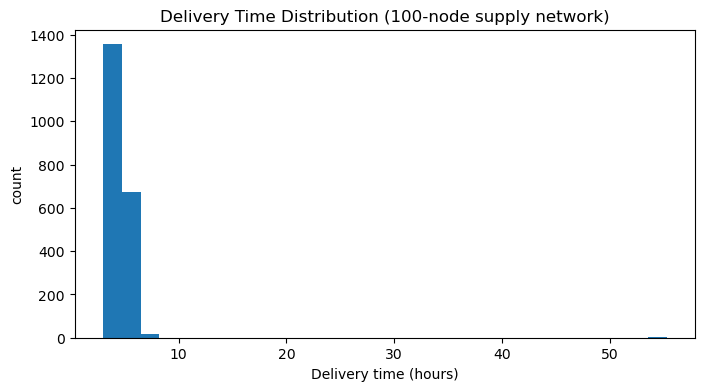

Created: 2084
Delivered: 2048
Service level: 0.983
Avg delivery time: 4.51
Blocked/retry events: 1963


In [8]:

plt.figure(figsize=(8, 4))
plt.hist(out["delivery_times"], bins=30)
plt.title("Delivery Time Distribution (100-node supply network)")
plt.xlabel("Delivery time (hours)")
plt.ylabel("count")
plt.show()

print("Created:", out["created"])
print("Delivered:", out["delivered"])
print("Service level:", round(out["service_level"], 3))
print("Avg delivery time:", round(out["avg_delivery_time"], 2))
print("Blocked/retry events:", out["blocked_orders"])

## Interpretation of Simulation Results

The simulation results provide insights into how the network performs under realistic operating conditions.

Key observations include:

- Delivery times depend strongly on warehouse processing capacity.
- Network congestion can occur when multiple routes share the same intermediate hubs.
- Disruptions in central nodes significantly affect overall system performance.

## 8) Inspect strongest active flow edges

In [9]:

def pretty_flow(flow, top_n: int = 40):
    items = sorted(flow.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    for (u, v), f in items:
        print(f"{u:>3}->{v:<3} | {NODE_NAMES[u]} -> {NODE_NAMES[v]} | {f:.2f} shipments/hour")

print("=== Top flow edges (Normal) ===")
pretty_flow(flow_normal, top_n=40)

print("\n=== Top flow edges (With warehouse failed) ===")
pretty_flow(flow_failed, top_n=40)

=== Top flow edges (Normal) ===
  0->6   | Super Source -> Supplier 6 | 16.00 shipments/hour
  0->3   | Super Source -> Supplier 3 | 15.00 shipments/hour
  0->1   | Super Source -> Supplier 1 | 14.00 shipments/hour
  0->2   | Super Source -> Supplier 2 | 13.00 shipments/hour
  1->25  | Supplier 1 -> Warehouse 5 | 12.00 shipments/hour
  2->22  | Supplier 2 -> Warehouse 2 | 12.00 shipments/hour
  0->4   | Super Source -> Supplier 4 | 12.00 shipments/hour
  0->5   | Super Source -> Supplier 5 | 12.00 shipments/hour
  0->9   | Super Source -> Supplier 9 | 12.00 shipments/hour
  0->11  | Super Source -> Supplier 11 | 12.00 shipments/hour
  3->23  | Supplier 3 -> Warehouse 3 | 11.00 shipments/hour
  4->21  | Supplier 4 -> Warehouse 1 | 11.00 shipments/hour
  6->25  | Supplier 6 -> Warehouse 5 | 10.00 shipments/hour
  8->21  | Supplier 8 -> Warehouse 1 | 10.00 shipments/hour
  0->8   | Super Source -> Supplier 8 | 10.00 shipments/hour
  5->23  | Supplier 5 -> Warehouse 3 | 9.00 shipments/hour

## 9) Critical-node analysis

This section ranks nodes by **structural criticality**. For each candidate node, we temporarily remove it from the network, recompute max flow, and measure how much total throughput is lost.

For the warehouse-focused analysis, a higher **capacity loss %** means the warehouse is more critical to network throughput.


=== Top 10 critical warehouses by max-flow loss ===
Rank  Node               Type        Normal TP MaxFlow after fail     Loss %
------------------------------------------------------------------------------
1     Warehouse 4        warehouse       29.00             190.00      3.55
2     Warehouse 1        warehouse       30.00             191.00      3.05
3     Warehouse 5        warehouse       35.00             195.00      1.02
4     Warehouse 15       warehouse        8.00             195.00      1.02
5     Warehouse 3        warehouse       33.00             196.00      0.51
6     Warehouse 2        warehouse       33.00             197.00      0.00
7     Warehouse 16       warehouse       14.00             197.00      0.00
8     Warehouse 9        warehouse        6.00             197.00      0.00
9     Warehouse 19       warehouse        6.00             197.00      0.00
10    Warehouse 13       warehouse        5.00             197.00      0.00


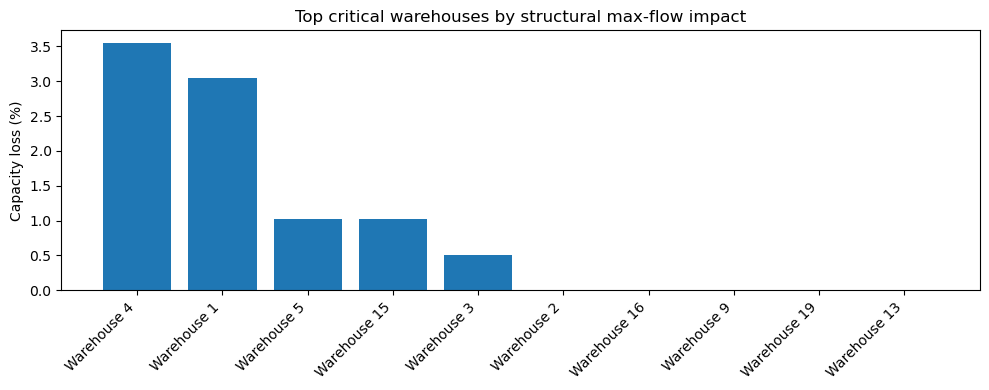


=== Top 15 critical business nodes overall ===
Rank  Node               Type        Normal TP MaxFlow after fail     Loss %
------------------------------------------------------------------------------
1     Supplier 6         supplier        16.00             181.00      8.12
2     Supplier 3         supplier        15.00             182.00      7.61
3     Supplier 1         supplier        14.00             183.00      7.11
4     Supplier 2         supplier        13.00             184.00      6.60
5     Supplier 4         supplier        12.00             185.00      6.09
6     Supplier 5         supplier        12.00             185.00      6.09
7     Supplier 9         supplier        12.00             185.00      6.09
8     Supplier 11        supplier        12.00             185.00      6.09
9     Supplier 8         supplier        10.00             187.00      5.08
10    Supplier 12        supplier         9.00             188.00      4.57
11    Supplier 7         supplier   

In [10]:

def node_throughput(flow: Dict[Tuple[int, int], float], node_id: int) -> float:
    inflow = sum(f for (u, v), f in flow.items() if v == node_id)
    outflow = sum(f for (u, v), f in flow.items() if u == node_id)
    return max(inflow, outflow)


def rank_critical_nodes(candidate_nodes: List[int]):
    results = []
    for nid in candidate_nodes:
        mf_fail, _ = compute_maxflow_with_failed_node(nid)
        loss_abs = mf_normal - mf_fail
        loss_pct = 100.0 * loss_abs / mf_normal if mf_normal > 0 else 0.0

        results.append({
            "node_id": nid,
            "node_name": NODE_NAMES[nid],
            "node_type": NODE_TYPES[nid],
            "normal_throughput": node_throughput(flow_normal, nid),
            "maxflow_after_failure": mf_fail,
            "capacity_loss_abs": loss_abs,
            "capacity_loss_pct": loss_pct,
        })

    results.sort(
        key=lambda r: (
            r["capacity_loss_pct"],
            r["normal_throughput"],
            r["capacity_loss_abs"]
        ),
        reverse=True
    )
    return results


def print_criticality_table(results, top_n: int = 10):
    print(
        f"{'Rank':<5} {'Node':<18} {'Type':<10} {'Normal TP':>10} "
        f"{'MaxFlow after fail':>18} {'Loss %':>10}"
    )
    print("-" * 78)
    for i, r in enumerate(results[:top_n], start=1):
        print(
            f"{i:<5} {r['node_name']:<18} {r['node_type']:<10} "
            f"{r['normal_throughput']:>10.2f} {r['maxflow_after_failure']:>18.2f} "
            f"{r['capacity_loss_pct']:>9.2f}"
        )


warehouse_criticality = rank_critical_nodes(WAREHOUSE_IDS)

print("=== Top 10 critical warehouses by max-flow loss ===")
print_criticality_table(warehouse_criticality, top_n=10)

top_n = 10
top = warehouse_criticality[:top_n]
labels = [r["node_name"] for r in top]
losses = [r["capacity_loss_pct"] for r in top]

plt.figure(figsize=(10, 4))
plt.bar(labels, losses)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Capacity loss (%)")
plt.title("Top critical warehouses by structural max-flow impact")
plt.tight_layout()
plt.show()

all_business_criticality = rank_critical_nodes(SUPPLIER_IDS + WAREHOUSE_IDS + CUSTOMER_IDS)

print("\n=== Top 15 critical business nodes overall ===")
print_criticality_table(all_business_criticality, top_n=15)


## Resilience Metric

To quantify how well the supply network performs under disruptions, we define a resilience metric based on throughput comparison.

Resilience is defined as:

Resilience = throughput_after_failure / normal_throughput

A value close to **1** indicates that the network maintains most of its capacity after disruption, while lower values indicate stronger performance degradation.

## 10) Extra experiments: demand surge, regional failures, combined critical-node failure, and resilience ratio

This section compares disruption scenarios using both structural and operational metrics. In addition to max-flow capacity loss, it computes the **resilience ratio**:

\[
\text{Resilience Ratio} = \frac{\text{disrupted max flow}}{\text{baseline max flow}}
\]

A resilience ratio of **1.0** means no structural throughput loss, while lower values indicate greater disruption impact.

=== Region composition ===
Region 1: 4 suppliers, 6 warehouses, 10 customers
Region 2: 3 suppliers, 6 warehouses, 10 customers
Region 3: 4 suppliers, 6 warehouses, 10 customers
Region 4: 6 suppliers, 6 warehouses, 10 customers
Region 5: 3 suppliers, 6 warehouses, 10 customers

=== Most critical business nodes ===
Most critical warehouse: Warehouse 4 | loss=3.55%
Most critical supplier: Supplier 6 | loss=8.12%

=== Scenario comparison ===


,scenario,failed_nodes,demand_multiplier,maxflow_after_failure,capacity_loss_pct,resilience_ratio,created,delivered,service_level,avg_delivery_time,blocked_orders
0,Region 4 supplier failure,"Supplier 6, Supplier 10, Supplier 14, Supplier...",1.0,143.0,27.41,0.726,2084,2046,0.9818,4.4764,1475
1,Region 1 supplier failure,"Supplier 3, Supplier 4, Supplier 9, Supplier 11",1.0,146.0,25.89,0.741,2084,2047,0.9822,4.4339,1487
2,Region 3 supplier failure,"Supplier 2, Supplier 5, Supplier 13, Supplier 17",1.0,159.0,19.29,0.807,2084,2046,0.9818,4.4636,989
3,Region 2 supplier failure,"Supplier 8, Supplier 12, Supplier 16",1.0,170.0,13.71,0.863,2084,2044,0.9808,4.4432,1479
4,Region 5 supplier failure,"Supplier 1, Supplier 7, Supplier 19",1.0,170.0,13.71,0.863,2084,2047,0.9822,4.3945,0
5,Critical warehouse + critical supplier failure,"Warehouse 4, Supplier 6",1.0,174.0,11.68,0.883,2084,2039,0.9784,4.5002,2959
6,Demand surge + critical warehouse + critical s...,"Warehouse 4, Supplier 6",1.3,174.0,11.68,0.883,2709,2661,0.9823,4.5445,3439
7,Region 4 warehouse failure,"Warehouse 4, Warehouse 15, Warehouse 16, Wareh...",1.0,180.0,8.63,0.914,2084,2043,0.9803,4.6554,7322
8,Region 1 warehouse failure,"Warehouse 1, Warehouse 6, Warehouse 7, Warehou...",1.0,191.0,3.05,0.970,2084,2044,0.9808,4.5332,2952
9,Region 5 warehouse failure,"Warehouse 5, Warehouse 18, Warehouse 19, Wareh...",1.0,195.0,1.02,0.990,2084,2038,0.9779,4.5265,4446


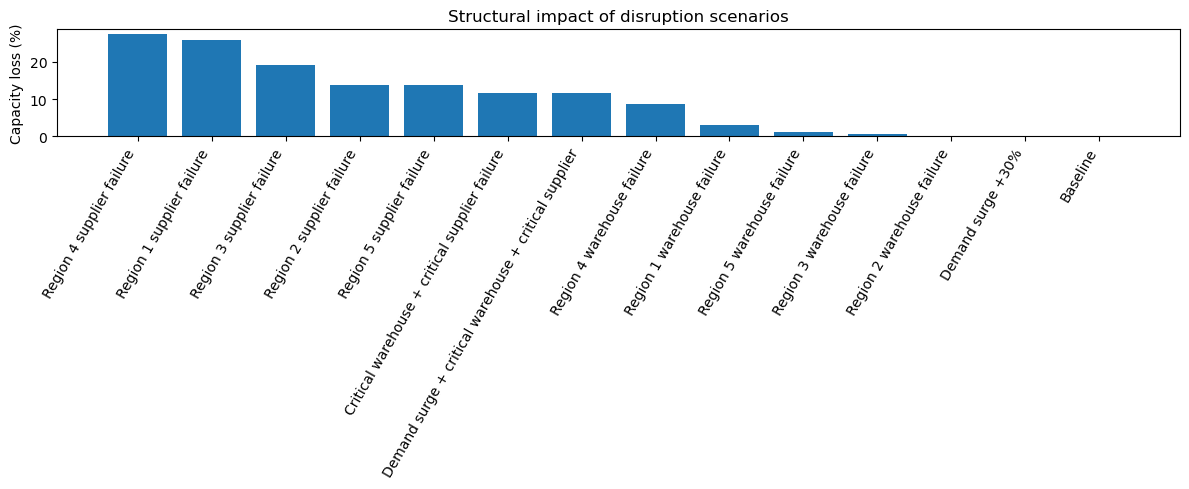

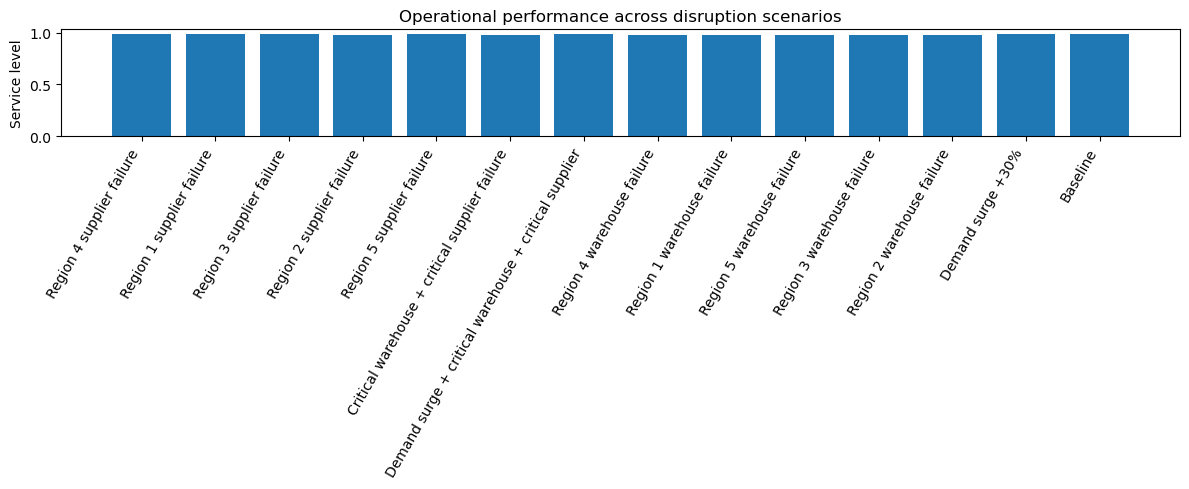

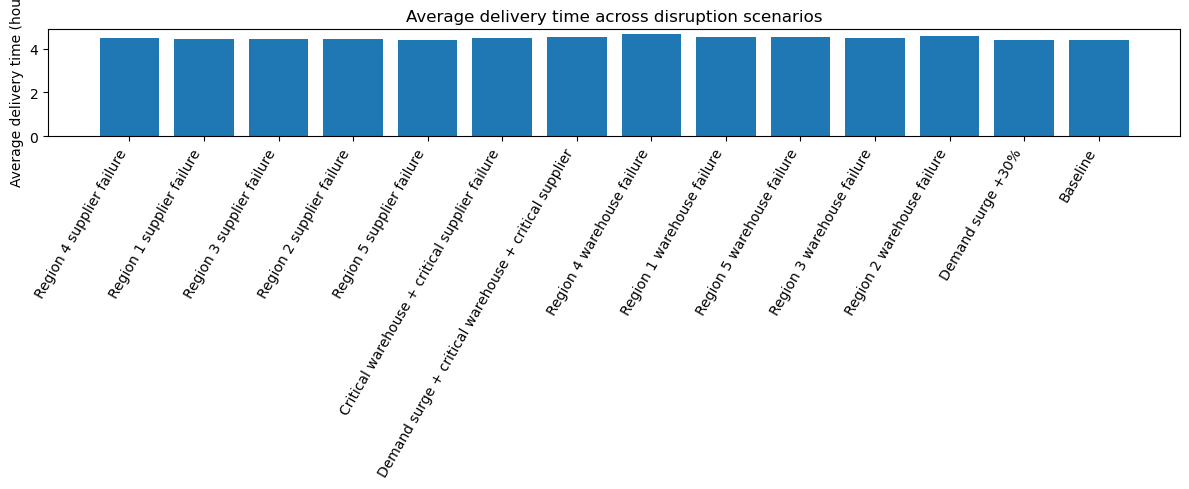

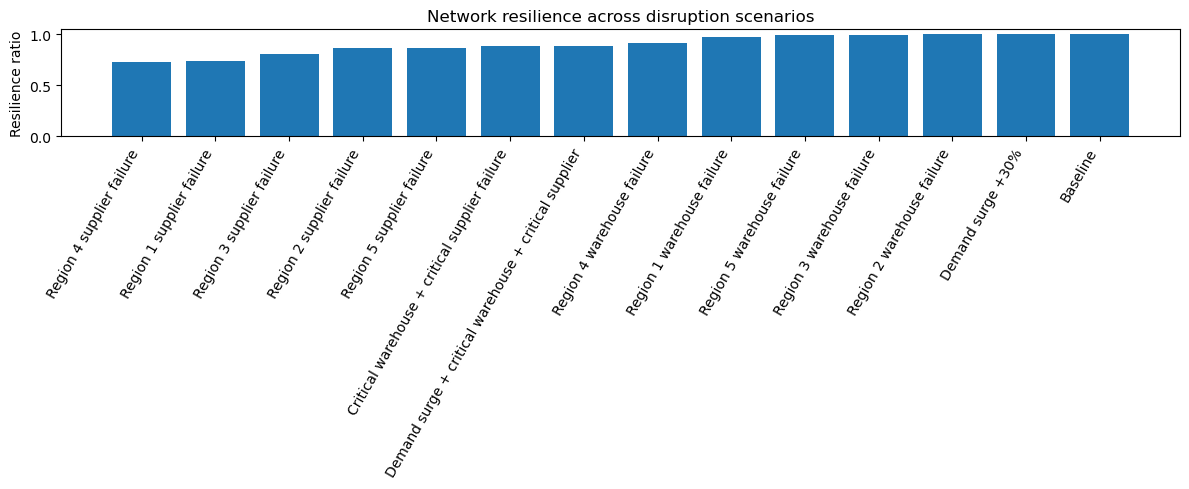

In [11]:

# ============================================================
# EXTRA EXPERIMENTS:
# 1) 30% demand surge
# 2) Regional warehouse failure (each region)
# 3) Regional supplier failure (each region)
# 4) Most critical warehouse + most critical supplier fail together
# ============================================================

import pandas as pd

REGION_NAMES = [f"Region {i+1}" for i in range(len(CUSTOMER_REGIONS))]

# -----------------------------
# Region mapping
# -----------------------------
WAREHOUSE_TO_REGION = {}
for r, ws in REGION_TO_PRIMARY.items():
    for w in ws:
        WAREHOUSE_TO_REGION[w] = r
for r, ws in REGION_TO_BACKUP.items():
    for w in ws:
        WAREHOUSE_TO_REGION[w] = r

CUSTOMER_TO_REGION = {}
for r, custs in enumerate(CUSTOMER_REGIONS):
    for c in custs:
        CUSTOMER_TO_REGION[c] = r

# assign each supplier to the region where it sends the most outbound capacity
SUPPLIER_TO_REGION = {}
for s in SUPPLIER_IDS:
    region_caps = defaultdict(float)
    for (u, v), cap in EDGE_CAP.items():
        if u == s and v in WAREHOUSE_TO_REGION:
            region_caps[WAREHOUSE_TO_REGION[v]] += cap

    SUPPLIER_TO_REGION[s] = max(region_caps, key=region_caps.get) if region_caps else 0

REGION_SUPPLIERS = {
    r: [s for s in SUPPLIER_IDS if SUPPLIER_TO_REGION[s] == r]
    for r in range(len(REGION_NAMES))
}
REGION_WAREHOUSES = {
    r: [w for w in WAREHOUSE_IDS if WAREHOUSE_TO_REGION[w] == r]
    for r in range(len(REGION_NAMES))
}
REGION_CUSTOMERS = {
    r: [c for c in CUSTOMER_IDS if CUSTOMER_TO_REGION[c] == r]
    for r in range(len(REGION_NAMES))
}

print("=== Region composition ===")
for r in range(len(REGION_NAMES)):
    print(
        f"{REGION_NAMES[r]}: "
        f"{len(REGION_SUPPLIERS[r])} suppliers, "
        f"{len(REGION_WAREHOUSES[r])} warehouses, "
        f"{len(REGION_CUSTOMERS[r])} customers"
    )

# -----------------------------
# Multi-node max-flow helper
# -----------------------------
def compute_maxflow_with_failed_nodes(failed_nodes=None):
    failed_nodes = failed_nodes or []
    active = [True] * N_TOTAL_NODES
    for nid in failed_nodes:
        active[nid] = False
    mf, fl = edmonds_karp_maxflow(active, EDGE_CAP, SRC, SNK)
    return mf, fl

# -----------------------------
# Find most critical warehouse and supplier
# -----------------------------
if "warehouse_criticality" not in globals():
    warehouse_criticality = rank_critical_nodes(WAREHOUSE_IDS)

supplier_criticality = rank_critical_nodes(SUPPLIER_IDS)

MOST_CRITICAL_WAREHOUSE = warehouse_criticality[0]["node_id"]
MOST_CRITICAL_SUPPLIER = supplier_criticality[0]["node_id"]

print("\n=== Most critical business nodes ===")
print(
    f"Most critical warehouse: {NODE_NAMES[MOST_CRITICAL_WAREHOUSE]} "
    f"| loss={warehouse_criticality[0]['capacity_loss_pct']:.2f}%"
)
print(
    f"Most critical supplier: {NODE_NAMES[MOST_CRITICAL_SUPPLIER]} "
    f"| loss={supplier_criticality[0]['capacity_loss_pct']:.2f}%"
)

# -----------------------------
# Simulation class for scenarios
# -----------------------------
class ScenarioSupplySim:
    def __init__(
        self,
        seed: int = 1,
        sim_time: float = 250.0,
        base_order_interval: float = 0.12,
        demand_multiplier: float = 1.0,
        retry_interval: float = 0.1,
        fail_nodes: Optional[List[int]] = None,
        t_fail: float = 90.0,
        duration: float = 50.0,
        scenario_name: str = "Scenario",
        verbose: bool = False,
    ):
        self.rng = random.Random(seed)
        self.env = simpy.Environment()

        self.sim_time = sim_time
        self.base_order_interval = base_order_interval
        self.demand_multiplier = demand_multiplier
        self.order_interval = base_order_interval / demand_multiplier
        self.retry_interval = retry_interval

        self.fail_nodes = fail_nodes or []
        self.t_fail = t_fail
        self.duration = duration
        self.scenario_name = scenario_name
        self.verbose = verbose

        self.nodes = []
        for nid in range(N_TOTAL_NODES):
            ntype = NODE_TYPES.get(nid, "unknown")

            if ntype in ("source", "sink"):
                cap = 999
                handling = 0.0
            elif ntype == "supplier":
                cap = 5
                handling = 0.08
            elif ntype == "warehouse":
                cap = 3
                handling = 0.20
            elif ntype == "customer":
                cap = 4
                handling = 0.05
            else:
                cap = 1
                handling = 0.0

            self.nodes.append(Node(self.env, nid, capacity=cap, handling_time=handling))

        self.edge_res = {
            e: simpy.Resource(self.env, capacity=max(1, int(EDGE_CAP[e] // 2)))
            for e in EDGE_CAP
        }

        self.travel = TravelTimeModel(self.rng)

        self.current_maxflow = 0.0
        self.current_flow = {}

        self.created = 0
        self.delivered = 0
        self.delivery_times = []
        self.blocked_orders = 0

    def active_mask(self) -> List[bool]:
        return [n.active for n in self.nodes]

    def recompute_flow(self):
        active = self.active_mask()
        mf, fl = edmonds_karp_maxflow(active, EDGE_CAP, SRC, SNK)
        self.current_maxflow = mf
        self.current_flow = fl

        if self.verbose:
            failed_now = [NODE_NAMES[n.node_id] for n in self.nodes if not n.active]
            print(
                f"[t={self.env.now:.1f}] {self.scenario_name} | "
                f"MaxFlow={mf:.2f} | inactive={failed_now if failed_now else 'None'}"
            )

    def shipment(self, sid: int):
        self.created += 1
        t0 = self.env.now
        cur, dest = SRC, SNK

        safety_hops = 0
        while cur != dest and safety_hops < 500:
            safety_hops += 1

            pol = flow_policy(self.current_flow, cur)
            if pol is None:
                self.blocked_orders += 1
                yield self.env.timeout(self.retry_interval)
                continue

            nxt = sample_next(self.rng, pol)
            edge = (cur, nxt)

            if not self.nodes[nxt].active:
                yield self.env.timeout(self.retry_interval)
                continue

            cap_per_hr = max(EDGE_CAP[edge], 1e-9)
            spacing = 1.0 / cap_per_hr

            with self.edge_res[edge].request() as req:
                yield req
                yield self.env.timeout(spacing)
                yield self.env.timeout(self.travel.sample(edge))

            node_obj = self.nodes[nxt]
            with node_obj.res.request() as rreq:
                yield rreq
                if node_obj.handling_time > 0:
                    yield self.env.timeout(node_obj.handling_time)

            cur = nxt

        if cur == dest:
            self.delivered += 1
            self.delivery_times.append(self.env.now - t0)

    def generator(self):
        sid = 0
        while self.env.now < self.sim_time:
            self.env.process(self.shipment(sid))
            sid += 1
            yield self.env.timeout(self.order_interval)

    def disruption(self):
        self.recompute_flow()

        if not self.fail_nodes:
            return

        yield self.env.timeout(self.t_fail)
        for nid in self.fail_nodes:
            self.nodes[nid].active = False

        if self.verbose:
            print(
                f"[t={self.env.now:.1f}] {self.scenario_name} FAILED: "
                + ", ".join(NODE_NAMES[nid] for nid in self.fail_nodes)
            )

        self.recompute_flow()

        yield self.env.timeout(self.duration)
        for nid in self.fail_nodes:
            self.nodes[nid].active = True

        if self.verbose:
            print(
                f"[t={self.env.now:.1f}] {self.scenario_name} RESTORED: "
                + ", ".join(NODE_NAMES[nid] for nid in self.fail_nodes)
            )

        self.recompute_flow()

    def run(self):
        self.env.process(self.generator())
        self.env.process(self.disruption())
        self.env.run(until=self.sim_time)

        service_level = self.delivered / self.created if self.created else 0.0
        avg_del = float(np.mean(self.delivery_times)) if self.delivery_times else float("nan")

        return {
            "created": self.created,
            "delivered": self.delivered,
            "service_level": service_level,
            "avg_delivery_time": avg_del,
            "blocked_orders": self.blocked_orders,
            "delivery_times": self.delivery_times,
        }

# -----------------------------
# Scenario runner
# -----------------------------
BASE_ORDER_INTERVAL = 0.12
SIM_TIME = 250
FAIL_TIME = 90
FAIL_DURATION = 50

def run_scenario(
    scenario_name: str,
    fail_nodes=None,
    demand_multiplier: float = 1.0,
    seed: int = 2,
    verbose: bool = False,
):
    fail_nodes = fail_nodes or []

    mf_after_fail, _ = compute_maxflow_with_failed_nodes(fail_nodes)
    loss_pct = 100.0 * (mf_normal - mf_after_fail) / mf_normal if mf_normal > 0 else 0.0
    resilience_ratio = mf_after_fail / mf_normal if mf_normal > 0 else 0.0

    sim = ScenarioSupplySim(
        seed=seed,
        sim_time=SIM_TIME,
        base_order_interval=BASE_ORDER_INTERVAL,
        demand_multiplier=demand_multiplier,
        retry_interval=0.1,
        fail_nodes=fail_nodes,
        t_fail=FAIL_TIME,
        duration=FAIL_DURATION,
        scenario_name=scenario_name,
        verbose=verbose,
    )
    out = sim.run()

    return {
        "scenario": scenario_name,
        "failed_nodes": ", ".join(NODE_NAMES[n] for n in fail_nodes) if fail_nodes else "None",
        "demand_multiplier": demand_multiplier,
        "maxflow_after_failure": round(mf_after_fail, 2),
        "capacity_loss_pct": round(loss_pct, 2),
        "resilience_ratio": round(resilience_ratio, 3),
        "created": out["created"],
        "delivered": out["delivered"],
        "service_level": round(out["service_level"], 4),
        "avg_delivery_time": round(out["avg_delivery_time"], 4),
        "blocked_orders": out["blocked_orders"],
    }

# -----------------------------
# Experiment set
# -----------------------------
scenario_results = []

scenario_results.append(
    run_scenario("Baseline", fail_nodes=[], demand_multiplier=1.0, seed=2)
)

scenario_results.append(
    run_scenario("Demand surge +30%", fail_nodes=[], demand_multiplier=1.3, seed=2)
)

for r in range(len(REGION_NAMES)):
    scenario_results.append(
        run_scenario(
            f"{REGION_NAMES[r]} warehouse failure",
            fail_nodes=REGION_WAREHOUSES[r],
            demand_multiplier=1.0,
            seed=2,
        )
    )

for r in range(len(REGION_NAMES)):
    scenario_results.append(
        run_scenario(
            f"{REGION_NAMES[r]} supplier failure",
            fail_nodes=REGION_SUPPLIERS[r],
            demand_multiplier=1.0,
            seed=2,
        )
    )

scenario_results.append(
    run_scenario(
        "Critical warehouse + critical supplier failure",
        fail_nodes=[MOST_CRITICAL_WAREHOUSE, MOST_CRITICAL_SUPPLIER],
        demand_multiplier=1.0,
        seed=2,
    )
)

scenario_results.append(
    run_scenario(
        "Demand surge + critical warehouse + critical supplier",
        fail_nodes=[MOST_CRITICAL_WAREHOUSE, MOST_CRITICAL_SUPPLIER],
        demand_multiplier=1.3,
        seed=2,
    )
)

df_scenarios = pd.DataFrame(scenario_results)
df_scenarios = df_scenarios.sort_values(
    by=["resilience_ratio", "service_level", "avg_delivery_time"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\n=== Scenario comparison ===")
display(df_scenarios)

plt.figure(figsize=(12, 5))
plt.bar(df_scenarios["scenario"], df_scenarios["capacity_loss_pct"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Capacity loss (%)")
plt.title("Structural impact of disruption scenarios")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(df_scenarios["scenario"], df_scenarios["service_level"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Service level")
plt.title("Operational performance across disruption scenarios")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(df_scenarios["scenario"], df_scenarios["avg_delivery_time"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Average delivery time (hours)")
plt.title("Average delivery time across disruption scenarios")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
plt.bar(df_scenarios["scenario"], df_scenarios["resilience_ratio"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Resilience ratio")
plt.title("Network resilience across disruption scenarios")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## Conclusion

This study demonstrates how supply-chain resilience can be analyzed using a combination of network optimization and simulation techniques.

The max-flow analysis identifies the theoretical throughput limits of the network, while the discrete event simulation captures operational dynamics such as delays and disruptions.

The experiments show that warehouse hubs play a critical role in maintaining supply-chain performance. Failures at these nodes significantly reduce throughput and increase delivery delays.

These findings highlight the importance of designing robust and redundant supply networks to ensure reliable logistics operations.